### https://www.kaggle.com/competitions/drawing-with-llms

In [1]:
# import kagglehub
# import pandas as pd
# import re

# train_path = kagglehub.competition_download('drawing-with-llms', 'train.csv')
# train = pd.read_csv(train_path)

# train.head(2)

In [2]:
import openai
import pandas as pd
import time
import os
from dotenv import load_dotenv
load_dotenv()
openai_api_key = os.getenv("OPENAI_API_KEY")
deepseek_api_key = os.getenv("DEEPSEEK_API_KEY")

In [3]:
from openai import OpenAI
client = OpenAI(api_key=deepseek_api_key, base_url="https://api.deepseek.com")

response = client.chat.completions.create(
    model="deepseek-chat",
    messages=[
        {"role": "system", "content": "You are a helpful assistant"},
        {"role": "user", "content": "Hello are you"},
    ],
    stream=False
)

print(response.choices[0].message.content)

Hello! Yes, I'm here and ready to assist you. How can I help you today? 😊


In [4]:
# Set up OpenAI client with your AP
#client = openai.OpenAI(api_key=openai_api_key)

# Function to get summary from OpenAI API
def get_topic():
    instruction = f"""
    I am participating SVG code generation competition. 
    
    The competition test data comprises about 500 descriptions of everyday objects and scenes from a variety of domains. Your goal is to create a model that generates SVG depictions of these descriptions.
    The descriptions have the following properties:
    The descriptions are of common, generic subjects. No brand name or trademark or personal name occurs in any description. No people, even in generic form, occur in any description.
    The subjects described span about a dozen categories.  The remaining categories in the public and private sets are unique to each set. 
    No description has more than 200 characters. The average length is around 50 characters.   

   
    I am planing to generate syntetic data for my small LLM training. can you please give me 200 topics relavant to the competion above? 
    Each topic should have varying charater from 10 to 200 with 50 charater as average. Half of the topics should be from landscapes, abstract, and fashion.

    Please give your respose in csv format. do not include charater length in response. only give response. 
    """

    try:
        response = client.chat.completions.create(
            model="deepseek-chat",
            messages=[
                {"role": "system", "content": "Generate a topic"},
                {"role": "user", "content": instruction}
            ],
            temperature=0.8,
            max_tokens=7200
        )
        return response.choices[0].message.content.strip()
    
    except Exception as e:
        print(f"Error: {e}")
        return None


In [5]:
# Function to get summary from OpenAI API
def get_svg_code(text):
    instruction = f"""
            Generate SVG code to visually represent the following text description, while respecting the given constraints.
            <constraints>
            * **Allowed Elements:** `svg`, `path`, `circle`, `rect`, `ellipse`, `line`, `polyline`, `polygon`, `g`, `linearGradient`, `radialGradient`, `stop`, `defs`
            * **Allowed Attributes:** `viewBox`, `width`, `height`, `fill`, `stroke`, `stroke-width`, `d`, `cx`, `cy`, `r`, `x`, `y`, `rx`, `ry`, `x1`, `y1`, `x2`, `y2`, `points`, `transform`, `opacity`
            </constraints>

            Please ensure that the generated SVG code is well-formed, valid, and strictly adheres to these constraints. 
            Focus on a clear and concise representation of the input description within the given limitations. 
            Always give the complete SVG code with nothing omitted. Never use an ellipsis.

            input description: {text}
            """

    try:
        response = client.chat.completions.create(
            model="deepseek-chat",
            messages=[
                {"role": "system", "content": "Generate SVG code as per instruction"},
                {"role": "user", "content": instruction}
            ],
            temperature=0.5,
            max_tokens=1024
        )
        return response.choices[0].message.content.strip()
    
    except Exception as e:
        print(f"Error: {e}")
        return None

In [8]:
# #generate random topic for svg training date
# import csv
# from io import StringIO
# import re

# topics_list=[]
# for i in range(1):

#     response=get_topic()
#     response = re.sub(r"```", "", response)
#     print('##### Response ##########')
#     print(response)
#     print('\n')
    
#     # # Extracting topics using regex
#     # topics = re.findall(r'"(.*?)"', response)
#     # # Removing the header "Topic"
#     # topics = [t for t in topics if t.lower() != "topic"]
#     # topics_list.extend(topics)
    
#     # Read CSV and convert to a clean list
#     csv_file = StringIO(response)
#     reader = csv.reader(csv_file)
#     next(reader)  # Skip header
#     next(reader)  # Skip header
#     topics = [row[0] for row in reader]
#     topics_list.extend(topics)
   
# print(len(topics_list))

In [9]:
# # Writing to a text file
# topics_string = '\n'.join(topics_list)
# # Write to a text file
# with open("topics_train2.txt", "w") as file:
#     file.write(topics_string)

In [10]:
import pandas as pd
df = pd.read_table("topics_train2.txt", header=None)
df.columns = ["topic"]
df=df.iloc[-500:]
df.shape

(500, 1)

In [11]:
from tqdm import tqdm
tqdm.pandas() 
df["response"] = df["topic"].progress_apply(get_svg_code)

100%|███████████████████████████████████████| 500/500 [3:32:44<00:00, 25.53s/it]


In [12]:
df.to_csv('response_train2.csv',index=False)

In [15]:
import re
def clean_svg(text):
    svg_code = re.search(r'```xml\n(.*?)\n```', text, re.DOTALL)
    
    if svg_code:
        extracted_svg = svg_code.group(1)
        return extracted_svg
    else:
        return '<svg </svg>'

In [16]:
df["svg_code"] = df["response"].progress_apply(clean_svg)

100%|██████████████████████████████████████| 500/500 [00:00<00:00, 86494.76it/s]


In [17]:
df['svg_code'].iloc[0]

'<svg viewBox="0 0 200 150" width="400" height="300" xmlns="http://www.w3.org/2000/svg">\n  <!-- Background -->\n  <rect x="0" y="0" width="200" height="150" fill="#87CEEB" />\n\n  <!-- Snow-covered ground -->\n  <rect x="0" y="100" width="200" height="50" fill="#F0F8FF" />\n\n  <!-- House -->\n  <rect x="70" y="70" width="60" height="30" fill="#8B4513" />\n  <polygon points="70,70 100,50 130,70" fill="#A0522D" />\n  <rect x="85" y="80" width="10" height="20" fill="#ADD8E6" />\n  <circle cx="95" cy="90" r="2" fill="#000000" />\n\n  <!-- Trees -->\n  <rect x="20" y="80" width="10" height="20" fill="#8B4513" />\n  <polygon points="15,80 35,80 25,60" fill="#228B22" />\n  <polygon points="15,75 35,75 25,55" fill="#228B22" />\n\n  <rect x="150" y="80" width="10" height="20" fill="#8B4513" />\n  <polygon points="145,80 165,80 155,60" fill="#228B22" />\n  <polygon points="145,75 165,75 155,55" fill="#228B22" />\n\n  <!-- Snowflakes -->\n  <circle cx="10" cy="20" r="2" fill="#FFFFFF" />\n  <ci

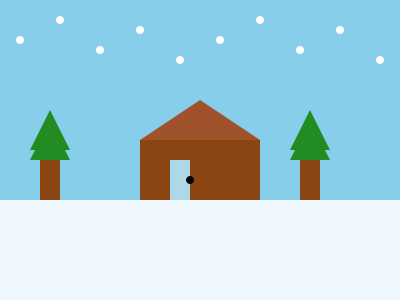

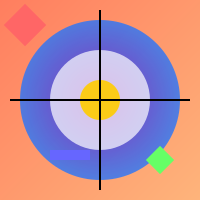

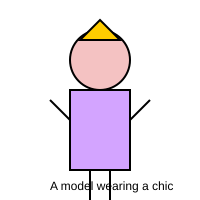

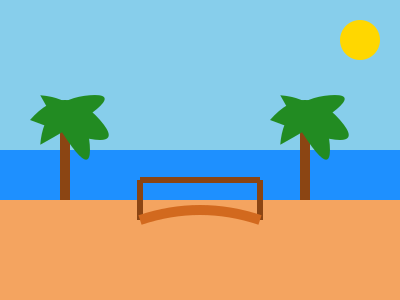

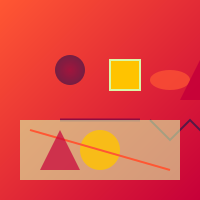

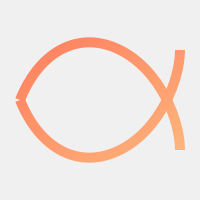

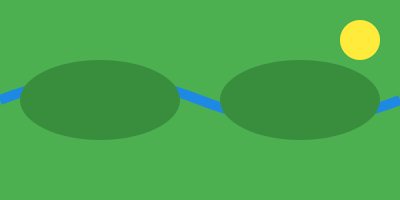

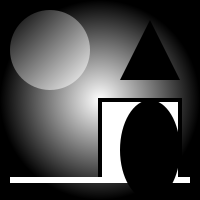

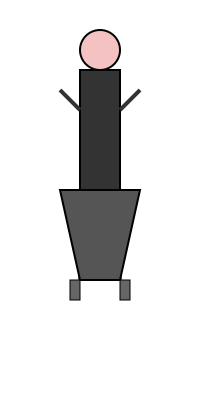

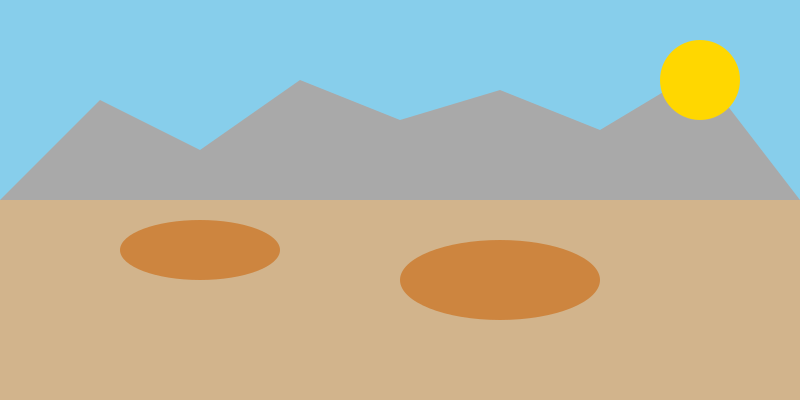

In [18]:
# We can play with our Model and render its SVG output (don't export!)
from IPython.display import SVG, display
for svg in df["svg_code"].iloc[:10]:
    #print(svg)
    display(SVG(svg))

In [19]:
from transformers import AutoProcessor, AutoModel
model = AutoModel.from_pretrained("google/siglip-so400m-patch14-384")
processor = AutoProcessor.from_pretrained("google/siglip-so400m-patch14-384")

In [20]:
import torch
from PIL import Image
import cairosvg
import os

def svgMetric(prompt, svg):
    try:
        # Convert SVG to PNG
        cairosvg.svg2png(svg, write_to="./tmp/temp.png")
        
        # Open and process the image
        image = Image.open('./tmp/temp.png').convert("RGB")
        texts = ["SVG illustration of " + prompt]
        inputs = processor(text=texts, images=image, padding="max_length", return_tensors="pt")
        
        # Inference without gradient tracking
        with torch.no_grad():
            outputs = model(**inputs)
        
        logits_per_image = outputs.logits_per_image
        probs = torch.sigmoid(logits_per_image)
        
        # Clean up temporary PNG file
        #os.remove('./tmp/temp.png')
        
        return probs[0][0].item()

    
    except Exception as e:
        print(f"An error occurred: {e}")
        return None




In [21]:
# Using apply to process each row in the DataFrame
df['score'] = df.progress_apply(lambda row: svgMetric(row['topic'], row['svg_code']), axis=1)


 39%|███████████████▉                         | 195/500 [05:21<07:48,  1.53s/it]

An error occurred: not well-formed (invalid token): line 1, column 5


 42%|█████████████████▏                       | 210/500 [05:42<07:14,  1.50s/it]

An error occurred: duplicate attribute: line 15, column 32


100%|█████████████████████████████████████████| 500/500 [13:19<00:00,  1.60s/it]


In [22]:
# Display results
print('mean gpt-4o score:',df['score'].mean())

mean gpt-4o score: 0.4873140333163284


In [23]:
df.to_csv('svg_score_train2.csv',index=False)

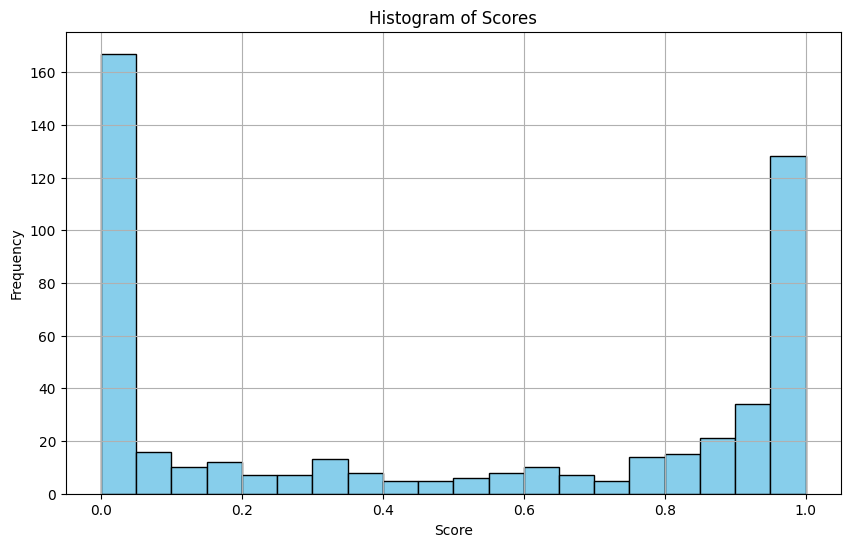

In [24]:
import matplotlib.pyplot as plt

# Plot histogram of the 'score' column
plt.figure(figsize=(10, 6))
plt.hist(df['score'], bins=20, color='skyblue', edgecolor='black')
plt.title('Histogram of Scores')
plt.xlabel('Score')
plt.ylabel('Frequency')
plt.grid(True)
plt.show()

In [25]:
count = (df['score'] > 0.6).sum()
print(f"Number of entries with score > 0.6: {count}")

Number of entries with score > 0.6: 234
